In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import scipy.stats as stats # for the target variables analysis

# Load datasets
train = pd.read_csv("ML_WP_data/train.csv")
test = pd.read_csv("ML_WP_data/test.csv")

In [2]:
# Checking the table
train.head()

,Id,reference_timestamp,fkl010h0_ANT,fkl010h0_BAS,fkl010h0_DAV,fkl010h0_DOL,fkl010h0_GVE,fkl010h0_INT,fkl010h0_LUG,fkl010h0_SIO,...,ure200h0_INT,ure200h0_LUG,ure200h0_SIO,ure200h0_STG,ure200h0_ZER,tre200h0_lag,tre200h0,target_tre200h0_plus12h,target_tre200h0_plus24h,target_tre200h0_plus48h
0,5526,2015-01-17 09:00:00,3.5,2.1,4.7,6.0,1.3,2.2,1.0,1.6,...,95.2,96.5,83.9,98.8,94.0,2.9,1.0,0.5,-3.2,-0.6
1,4450,2014-01-23 05:00:00,0.7,1.0,0.4,9.6,1.6,1.0,0.6,0.4,...,88.1,83.2,83.9,86.3,52.8,0.5,-0.4,4.5,0.9,-3.4
2,16114,2024-09-15 18:00:00,4.2,2.3,1.9,6.1,5.0,2.6,4.0,5.3,...,71.8,11.8,55.0,71.0,71.5,10.4,11.6,5.1,10.9,14.2
3,6968,2016-05-11 19:00:00,6.0,1.7,0.5,5.6,1.7,2.7,0.6,0.8,...,89.8,95.3,94.5,93.1,95.6,6.6,8.3,-2.4,-1.5,12.3
4,11568,2020-07-23 06:00:00,1.1,1.3,1.7,5.1,0.9,1.9,0.7,1.0,...,92.1,75.4,92.2,86.9,91.6,17.9,17.3,25.0,16.6,14.5


In [3]:
# Checking the table: weather data from Bern
test.head()

,Id,reference_timestamp,fkl010h0_ANT,fkl010h0_BAS,fkl010h0_DAV,fkl010h0_DOL,fkl010h0_GVE,fkl010h0_INT,fkl010h0_LUG,fkl010h0_SIO,...,ure200h0_DAV,ure200h0_DOL,ure200h0_GVE,ure200h0_INT,ure200h0_LUG,ure200h0_SIO,ure200h0_STG,ure200h0_ZER,tre200h0_lag,tre200h0
0,15942,2024-07-20 12:00:00,4.7,1.2,3.8,3.8,2.7,2.3,1.7,2.2,...,47.9,61.0,49.8,49.4,59.3,44.5,60.9,37.2,27.8,28.0
1,16408,2024-12-22 14:00:00,3.6,5.5,1.0,15.6,3.9,5.6,1.7,2.6,...,85.2,99.8,76.8,76.6,87.1,82.0,86.6,86.1,3.8,3.1
2,6441,2015-11-18 07:00:00,1.2,4.1,0.3,10.4,0.9,1.2,1.4,0.6,...,81.1,100.0,94.6,100.0,84.4,89.5,71.6,84.6,4.4,11.7
3,12093,2021-01-14 04:00:00,8.3,6.3,1.1,16.8,1.6,5.0,0.9,3.7,...,92.9,100.0,98.0,100.0,76.5,82.8,90.4,92.2,1.7,4.4
4,6653,2016-01-27 21:00:00,1.7,2.8,0.6,11.1,2.4,0.8,0.3,1.2,...,64.1,51.8,86.8,100.0,89.3,76.2,36.6,63.1,1.4,3.6


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9343 entries, 0 to 9342
Data columns (total 77 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Id                       9343 non-null   int64  
 1   reference_timestamp      9343 non-null   object 
 2   fkl010h0_ANT             9336 non-null   float64
 3   fkl010h0_BAS             9340 non-null   float64
 4   fkl010h0_DAV             9341 non-null   float64
 5   fkl010h0_DOL             9339 non-null   float64
 6   fkl010h0_GVE             9342 non-null   float64
 7   fkl010h0_INT             9341 non-null   float64
 8   fkl010h0_LUG             9342 non-null   float64
 9   fkl010h0_SIO             9341 non-null   float64
 10  fkl010h0_STG             9338 non-null   float64
 11  fkl010h0_ZER             9337 non-null   float64
 12  fkl010h3_ANT             9342 non-null   float64
 13  fkl010h3_BAS             9343 non-null   float64
 14  fkl010h3_DAV            

In [5]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2336 entries, 0 to 2335
Data columns (total 74 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2336 non-null   int64  
 1   reference_timestamp  2336 non-null   object 
 2   fkl010h0_ANT         2336 non-null   float64
 3   fkl010h0_BAS         2336 non-null   float64
 4   fkl010h0_DAV         2336 non-null   float64
 5   fkl010h0_DOL         2336 non-null   float64
 6   fkl010h0_GVE         2336 non-null   float64
 7   fkl010h0_INT         2336 non-null   float64
 8   fkl010h0_LUG         2336 non-null   float64
 9   fkl010h0_SIO         2336 non-null   float64
 10  fkl010h0_STG         2336 non-null   float64
 11  fkl010h0_ZER         2336 non-null   float64
 12  fkl010h3_ANT         2336 non-null   float64
 13  fkl010h3_BAS         2336 non-null   float64
 14  fkl010h3_DAV         2336 non-null   float64
 15  fkl010h3_DOL         2336 non-null   f

In [6]:
# Exploratory Data Analysis

## Missing Value Summary and Dispersion Analysis

In [7]:
# Getting the variables with missing values, the amount and the percentage
missing_summary = (
    pd.DataFrame({
        'Data_Type': train.dtypes,
        'Missing_Values': train.isnull().sum(),
        'Percent_Missing': (train.isnull().sum() / len(train) * 100).round(2)
    })
    .query("Missing_Values > 0")
    .sort_values(by='Missing_Values', ascending=False)
)

# Getting a statistical summary of the dataset (like what .describe() returns)
summary_stats = train.describe(include='all').transpose()

# Merging missing summary with descriptive stats for better insight
merged_summary = missing_summary.merge(
    summary_stats[['mean', 'std', 'min', '25%', '50%', '75%', 'max']],
    left_index=True,
    right_index=True,
    how='left'
)

print(merged_summary.to_string())

# Print the total number of variables with missing values
print(f"\nTotal variables with missing values: {len(missing_summary)}")

# Identify all target columns (the temperature variables we need to predict)
target_columns = train.filter(like='target').columns.tolist()


                        Data_Type  Missing_Values  Percent_Missing        mean         std    min     25%    50%     75%     max
fkl010h0_ANT              float64               7             0.07    3.396026    2.570304    0.3     1.1    2.6     5.3    15.1
prestah0_LUG              float64               6             0.06  981.283742    7.430135  944.1   977.2  981.4   985.7  1008.4
fkl010h0_ZER              float64               6             0.06    1.768716    1.575561    0.0     0.8    1.1     2.1    14.0
rre150h0_SIO              float64               6             0.06    0.069112    0.401013    0.0     0.0    0.0     0.0    15.0
rre150h0_BAS              float64               6             0.06    0.096958    0.603455    0.0     0.0    0.0     0.0    19.5
tre200h0_ZER              float64               5             0.05    5.568312    7.859445  -15.8    -0.5    5.2    11.2    30.5
target_tre200h0_plus12h   float64               5             0.05   10.234761    8.151299  -14.5

## Key observations of the Missing Value Summary and Dispersion Analysis

* **Precipitation (`rre150h0_*`)** – *rre150h0: Precipitation; hourly total*  
  * Most hourly values are zero (25%, 50%, 75% = 0).  
  * Maximum values up to 41.7 mm/hour (e.g., Lugano) are realistic for Swiss storms.  
  * Very small means and large standard deviations indicate strong right skew.  
  * These “outliers” are genuine rainfall events, not errors.

* **Global radiation (`gre000h0_*`)** – *gre000h0: Global radiation; hourly mean*  
  * Many zeros at night; daytime values reach up to around 1000 W/m².  
  * High standard deviation (~250 W/m²) reflects day–night cycles.  
  * Strongly skewed, possibly bimodal distribution (night vs. day).

* **Atmospheric pressure (`prestah0_*`)** – *prestah0: Atmospheric pressure at barometric altitude (QFE); hourly mean*  
  * Narrow ranges (~7 hPa std) consistent with expected altitudes.  
  * No missing or implausible values detected.  
  * Excellent sensor consistency across stations.

* **Temperature (`tre200h0_*`)** – *tre200h0: Temperature at 2 m above ground; hourly mean*  
  * Mean temperature varies by station (≈ 4 °C in Davos/Andermatt, ≈ 13 °C in Lugano).  
  * Ranges from −23 °C to +38 °C, plausible for Swiss seasonal extremes.  
  * Differences in means due to elevation, not data quality issues.

* **Humidity (`ure200h0_*`)** – *ure200h0: Relative air humidity 2 m above ground; hourly mean*  
  * Mostly within 0–100 %; rare minima (≈ 2–3 %) possible in very dry air.  
  * Some near-100 % readings are expected under saturated conditions.  
  * Physically bounded variable; clipping can be applied if needed.

* **Wind (`fkl010h*_*`)** – *fkl010h1: Gust peak (one second); hourly maximum in m/s*  
  * Substantial variability; some locations (La Dôle, Andermatt) show strong gusts.  
  * Distributions are right-skewed with high maxima but physically plausible.  
  * Reflects natural geographic differences rather than anomalies.

🎯 **Target columns in the dataset:**
- target_tre200h0_plus12h  
- target_tre200h0_plus24h  
- target_tre200h0_plus48h  

### Preprocessing recommendations

| Variable group                                       | Issues identified                    | Suggested action                                                |
| ---------------------------------------------------- | ------------------------------------ | --------------------------------------------------------------- |
| **Pressure**                                         | None                                 | Keep as is                                                      |
| **Temperature**                                      | Different baselines between stations | Apply Z-score normalisation per station                         |
| **Humidity**                                         | Physically bounded (0–100 %)         | Clip values to [0, 100]                                         |
| **Precipitation, Radiation, Wind**                   | Heavy right skew, many zeros         | Optionally apply log(1 + x) transformation before linear models |
| **Targets (`target_tre200h0_+12h`, `+24h`, `+48h`)** | No missing values                    | Keep as dependent variables                                     |

| Code  | Station    | Region    | Terrain type        |
|-------|-------------|-----------|---------------------|
| BAS   | Basel       | North     | Lowland             |
| GVE   | Genève      | West      | Lowland             |
| INT   | Interlaken  | Central   | Valley              |
| SIO   | Sion        | South     | Alpine valley       |
| STG   | St-Gallen   | Northeast | Foothills           |
| DAV   | Davos       | East      | High Alpine         |
| ZER   | Zermatt     | South     | High Alpine         |
| ANT   | Andermatt   | Central   | Mountain pass       |
| DOL   | La Dôle     | West      | Jura mountains      |
| LUG   | Lugano      | South     | Pre-Alpine / Ticino |

In [8]:
# Select only numeric columns
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()

# If you want to exclude targets, do it here:
targets = ["target_tre200h0_plus12h", "target_tre200h0_plus24h", "target_tre200h0_plus48h"]
numeric_cols = [c for c in numeric_cols if c not in targets]

# Function to detect outliers using the IQR rule
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return outliers

# Apply to all numeric columns
outlier_summary = {}
for col in numeric_cols:
    n_outliers = len(detect_outliers(train, col))
    outlier_summary[col] = n_outliers

# Convert to DataFrame for easier analysis
outlier_df = pd.DataFrame(list(outlier_summary.items()), columns=["Variable", "Outlier_Count"])
outlier_df["Outlier_%"] = (outlier_df["Outlier_Count"] / len(train)) * 100
outlier_df.sort_values(by="Outlier_%", ascending=False, inplace=True)

display(outlier_df.head(20))  # show top 15 variables with most outliers


,Variable,Outlier_Count,Outlier_%
44,rre150h0_DOL,1667,17.842235
41,rre150h0_ANT,1423,15.230654
49,rre150h0_STG,1417,15.166435
43,rre150h0_DAV,1266,13.550252
46,rre150h0_INT,1199,12.833137
30,gre000h0_ZER,1186,12.693996
26,gre000h0_INT,1158,12.394306
8,fkl010h0_SIO,1138,12.180242
29,gre000h0_STG,1060,11.345392
22,gre000h0_BAS,1029,11.013593


Como vemos en la tabla, hay variables con gran porcentaje de observaciones consideradas extremas. Sin embargo, al comprobar la localización geográfica de esa observación, podemos concluir que más que valores extremos propios de un error de medición, estos valores se deben a la gran variabilidad geográfica y por ende meteorológica de Suiza.
En otras palabras, el IQR no toma en consideración el lugar en el que las mediciones fueron tomadas. Para referencia, hemos incluido una tabla con las localizaciones de las estaciones meteorológicas de esta base de datos.
En conclusión, no recomendamos eliminar los valores extremos, ya que, por ejemplo, una lluvia intensa en Davos, podría predecir una caída de temperaturas en Berna en las próximas 24h.

Winsorisation is not recommended either since the outliers are likely a real phenomenon and not measurement errors and winsorising would distort the weather distribution.

What could be done is normalising the values per weather station since eachone operates under differnt climate conditions. PCA is only recommended for linear models, right? for prediction its better regularisation?



In [ ]:
targets = ["target_tre200h0_plus12h", "target_tre200h0_plus24h", "target_tre200h0_plus48h"]

fig, axes = plt.subplots(len(targets), 3, figsize=(15, 12))

for i, target_col in enumerate(targets):
    # Histogram
    axes[i, 0].hist(train[target_col], bins=50, edgecolor='black', alpha=0.7)
    axes[i, 0].set_title(f"{target_col} – Distribution")
    axes[i, 0].set_xlabel("Temperature (°C)")
    axes[i, 0].set_ylabel("Frequency")

    # Boxplot
    axes[i, 1].boxplot(train[target_col].dropna(), vert=True)
    axes[i, 1].set_title(f"{target_col} – Boxplot")
    axes[i, 1].set_ylabel("Temperature (°C)")

    # Q–Q plot
    stats.probplot(train[target_col].dropna(), dist="norm", plot=axes[i, 2])
    axes[i, 2].set_title(f"{target_col} – Q–Q Plot vs Normal")

plt.tight_layout()
plt.show()


Como vemos en los histogramas de arriba, las tres variables objetivo están normalmente distribuidas y son simétricas en torno a, más o menos, 10 grados centigrados. el rango de dichas vairables, (+/- -15º hasta +25ºC) es también metorológicamente plausible y muestra la variablidad estacional. Los boxplots confirman esto, pocas observaciones por debajo de los 10 grados o por envcima de los 35º. Además, los IQR son consistentes a través de las tres variable sobjetivo. Por último, los QQplots confirman una distribución muy cercana a la normal, con una ligera desviación de la distribución normal en valores extremos, posiblemente a causa de eventos meteorológicos extremos (heladas extremas u olas de calor). Conforme el horizonte de la predicción se hace más grande, vemos como ligeramente, la distribución es menos normal.

Necesitariamos box cox transformation? no no?

In [ ]:
targets = ["target_tre200h0_plus12h", "target_tre200h0_plus24h", "target_tre200h0_plus48h"]

for t in targets:
    clean_series = train[t].dropna()  # remove missing values
    clean_series = clean_series[np.isfinite(clean_series)]  # remove inf/-inf if any
    skew = stats.skew(clean_series)
    kurt = stats.kurtosis(clean_series)
    print(f"{t}: Skewness = {skew:.3f}, Kurtosis = {kurt:.3f}")

target_tre200h0_plus12h: Skewness = 0.224, Kurtosis = -0.618
target_tre200h0_plus24h: Skewness = 0.232, Kurtosis = -0.592
target_tre200h0_plus48h: Skewness = 0.204, Kurtosis = -0.651


In [ ]:
Los resultados que vimos en el histograma, boxplot y QQplot de arriba son confirmados por el análisis de skwenness. Al estar las tres variables objetivos con una skewness baja (sobre los 0.2 puntos), esto nos indica que hay ligreamente más temperaturas sobre cero que inferiores, cosa dentro de lo normal en mediciones de temperatura.
Respecto a la kurtosis, vemos como las tres variables tienen una ligera kurtosis negativa, indicando que las distribuciones son algo más planas y con colas más ligeras que una distribución normal.

## Missing Values

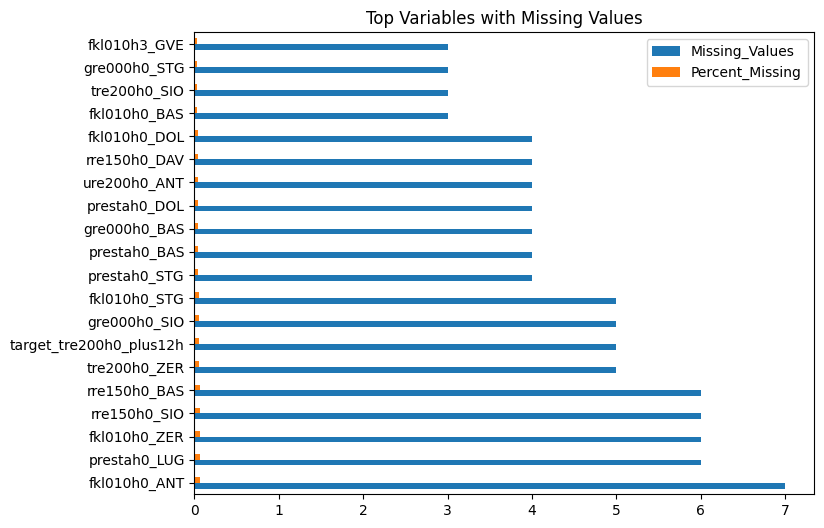

In [9]:
missing_summary.head(20).plot(kind='barh', figsize=(8,6))
plt.title("Top Variables with Missing Values")
plt.show()

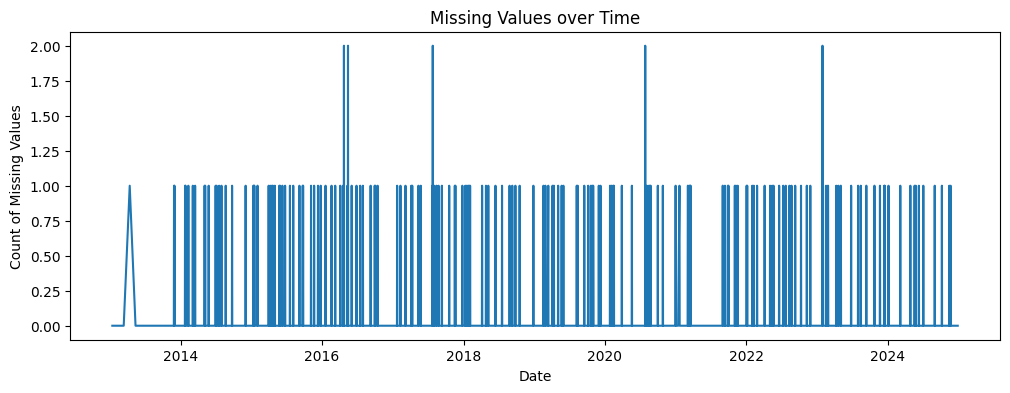

In [10]:
# Convert timestamp to datetime format
train['reference_timestamp'] = pd.to_datetime(train['reference_timestamp'])

# Count how many missing values each observation (row) has
train['missing_count'] = train.isnull().sum(axis=1)

# Group by date and sum up missing values across all stations for that day
(train
 .groupby(train['reference_timestamp'].dt.date)['missing_count']
 .sum()
 .plot(figsize=(12,4), title="Missing Values over Time"))

plt.ylabel("Count of Missing Values")
plt.xlabel("Date")
plt.show()


In [11]:
# Confirm the maximum number of missing values per row
train['missing_count'].max()

# Ensure reference_timestamp is a datetime type
train['reference_timestamp'] = pd.to_datetime(train['reference_timestamp'], errors='coerce')
# Group by date and sum the total missing values per day
missing_by_date = (
    train
    .groupby(train['reference_timestamp'].dt.date)['missing_count']
    .sum()
    .sort_values(ascending=False)
)
# Show top 10 dates with most missing values
missing_by_date.head(10)

reference_timestamp
2016-04-23    2
2016-05-14    2
2017-07-26    2
2020-07-28    2
2023-01-30    2
2024-10-08    1
2024-09-01    1
2024-07-04    1
2024-06-11    1
2024-05-26    1
Name: missing_count, dtype: int64

As we see in the plot above, missing values in train dataset seem to be rare and randomly distributed over time. Particularly, there is no clustering of missing data nor long gaps in which missing data was absent. This could mean that there is no systematic sensor failure or that there is no bias that would require time-aware imputation. In other words, these missing values are random noise. Lastly, no row has more than one missing value.

On the table we see the top 10 timestamps with greater number of missing values. We have only 5 dates in which there are two missing readings. So, there are no temporal clustering and this missingness is negligible. We could treat this as random noise (Missing Completely at Random: MCAR).

Considering all this facts, we could impute them via simple imputation as it would not introduce bias into our model.

## Posible code to drop nas or impute values

In [12]:
# Given the amount and patterns of missing data, we could delete the observations with missing values
train_drop = train.dropna()
print(f"Rows before drop: {len(train)}, after drop: {len(train_drop)}")

# or impute these values with mean values
train_mean_imp = train.fillna(train.mean(numeric_only=True))
# or with median values (robust to outliers)
train_median_imp = train.fillna(train.median(numeric_only=True))

# ---- Verify that imputation worked ----
print("\nRemaining missing values after mean imputation:")
print(train_mean_imp.isnull().sum().sum())

print("\nRemaining missing values after median imputation:")
print(train_median_imp.isnull().sum().sum())

Rows before drop: 9343, after drop: 9157

Remaining missing values after mean imputation:
0

Remaining missing values after median imputation:
0


## Correlation Analysis

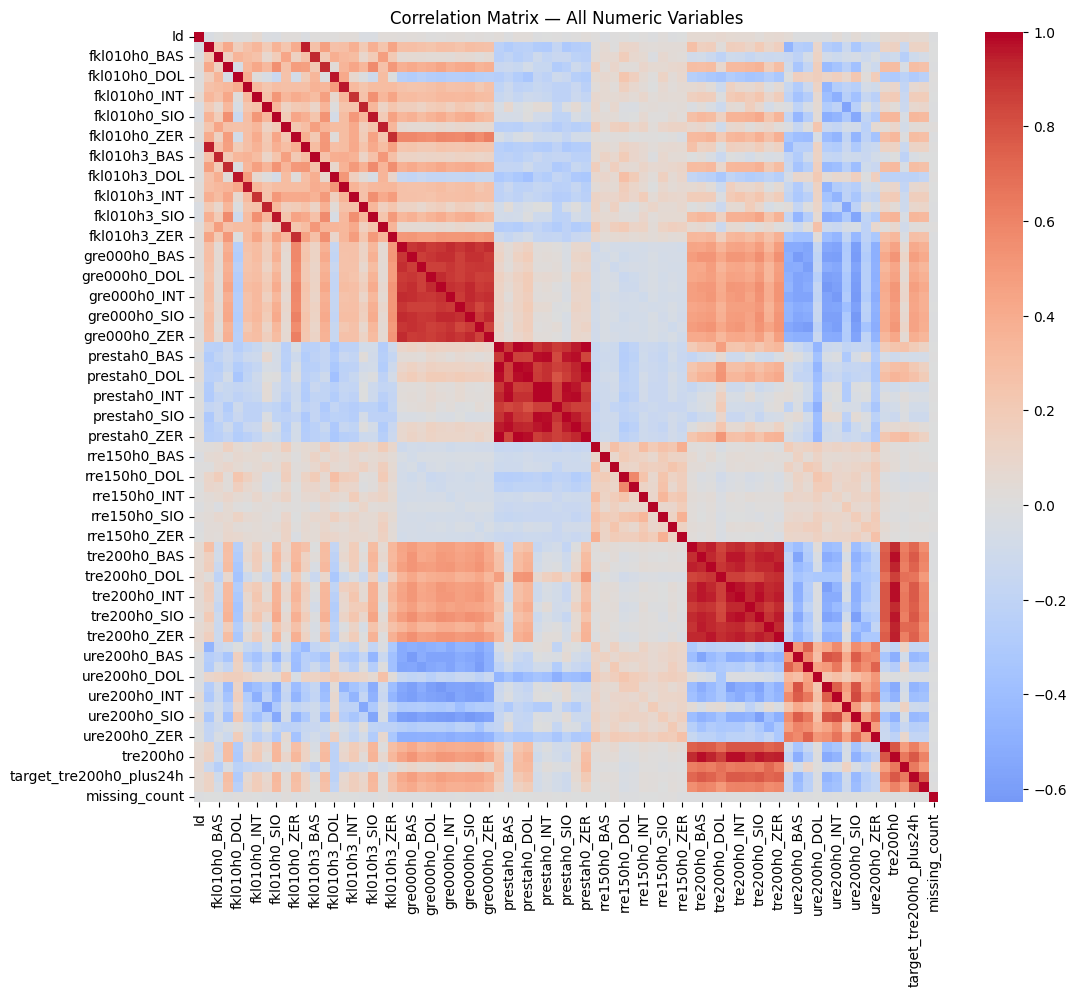

In [13]:
# Compute the correlation matrix for all numeric variables
corr = train.corr(numeric_only=True)

# Display the overall heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix — All Numeric Variables")
plt.show()

Vemos como hay una gran correlación intravariable en cada estación meteorológica como vemos en `gre000h0` (radiación) o en `prestah0` (presión atmosférica). Esto no es anómalo puesto que las estaciones meteorológicas son espacialmente coherentes, en otras palabras, las temperaturas y presiones atmosféricas se mueven harmoniosamente. Del mismo modo, hay débiles pero estructuradas cross variable correlations. Por ejemplo, `tre200h0` (temperatura) está correlacionada positivamente con `gre000h0` (radiación) y negativamente con `ure200h0` (humedad). De igual modo, `rre150h0`(precipitaciones) está correlacionada negativamente con `gre000h0` (radiación), lo que nos indica consitencia en términos meteorológicos (los valores de las variables están dentro de los rangos esperados para Sui)

Sin mebargo, la alta correlación entre variables implica multicolinearidad (explciar qué es?) pudiendo afectar el ajuste de ciertos modelos.

# Predictor Transformation

First we would normalise or standardise all the predictors (standardscaler)
Then we might want to do a PCA

In [ ]:
# Z-score normalisation per variable (per station)
for col in train.columns:
    if any(prefix in col for prefix in ['fkl010h', 'gre000h0', 'rre150h0', 'prestah0', 'ure200h0', 'tre200h0']):
        train[col] = (train[col] - train[col].mean()) / train[col].std()

# or better this one right? since it keeps mean and sd?

scaler = StandardScaler()
cols_to_scale = [c for c in train.columns if any(p in c for p in 
                 ['fkl010h', 'gre000h0', 'rre150h0', 'prestah0', 'ure200h0', 'tre200h0'])]

train[cols_to_scale] = scaler.fit_transform(train[cols_to_scale])


Given the few missing values

Missing Values Analysis (MVA)
To avoid bias and understand the data-generating process
No need of continuing the Missing values analysis with test dataset, right?

Do we fill missing values on train dataset with the column mean?
train = train.fillna(train.mean(numeric_only=True))
or with median imputation?
train = train.fillna(train.median(numeric_only=True))

With bootstrap? not yet
kNN imputer?


Ver qué columnas se ven más afectadas por valores nulos

Probamos eliminando primero, ver el porcentaje de valores nulos y en qué variables aparecen y en qué observaciones aparecen. sustitutir nas en columnas con más nulos

Outliers: analisis, quitar si son pocos

Correlación

una variable con alta variabilidad (alta dt). no imputar media, sino mediana?


In [ ]:
train[train.isnull().any(axis=1)]